<a href="https://colab.research.google.com/github/kartikvarma/Learning-ModelToAgent/blob/main/AI_And_ML_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 1**

## **Day 1**

1. **Tensors: The DNA of AI**

    Think of a Tensor as a multi-dimensional array (like a NumPy array) that can live on a GPU.

      *   A 0-D tensor is a scalar (a single number).
      *   A 1-D tensor is a vector.
      *   A 2-D tensor is a matrix.
      
      In AI, everything—images, words, or sounds—is converted into these numeric tensors.

2. **Autograd: The Magic of Learning**

    In the old days, you had to manually calculate the derivative (gradient) of your math functions to update model weights. PyTorch has Autograd. When you perform operations on tensors, PyTorch builds a computational graph. When you call .backward(), it automatically calculates the gradient of the loss with respect to every weight in your model.

3. **The Training Loop**

    Every model, from a simple line-recognizer to GPT-4, follows this loop:
      *  Forward Pass: Pass data through the model to get a prediction.
      *  Calculate Loss: Compare the prediction to the truth (How wrong are we?).
      *  Zero Grads: Clear out old math from the previous step.
      *  Backward Pass: Calculate the gradients (Backpropagation).
      *  Optimizer Step: Adjust the weights slightly to make the loss smaller.

### **Exercise1 : Setup and Tensor**

In [2]:
import torch

# 1. Check if GPU is available (Colab free tier provides a T4 GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Create a Tensor (like a list of data)
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data).to(device) # Move it to the GPU!

# 3. Operations
y_data = x_data * 10
print(f"Original Tensor:\n{x_data}")
print(f"Multiplied Tensor on GPU:\n{y_data}")

# 4. The 'DNA' Check
print(f"Shape: {x_data.shape}")
print(f"Datatype: {x_data.dtype}")

Using device: cuda
Original Tensor:
tensor([[1, 2],
        [3, 4]], device='cuda:0')
Multiplied Tensor on GPU:
tensor([[10, 20],
        [30, 40]], device='cuda:0')
Shape: torch.Size([2, 2])
Datatype: torch.int64


### **Homework**

**Your Mission (1 Hour)**

1. Create a tensor of size (3, 3) filled with random numbers using torch.rand.
2. Move that tensor to the GPU.
3. Perform a matrix multiplication with another random tensor using torch.matmul().
4. Research: Look up what tensor.view() does and try to reshape a (4, 4) tensor into a (2, 8) tensor.

In [27]:
### Solutions

# Create a tensor of size (3, 3) filled with random numbers using torch.rand.
rand_data3x3 = torch.rand(size=(3,3))

print(rand_data3x3)

# Move that tensor to GPU
x_rand_data3x3 = rand_data3x3.to(device)
print(f"Random Tensor on GPU:\n{x_rand_data3x3}")

# Perform a matrix multiplication with another random tensor using torch.matmul().

y_rand_data3x3 = x_rand_data3x3.matmul(torch.rand(size=(3,3)).to(device))

print(f"Multiplied Tensor on GPU:\n{y_rand_data3x3}")

# Research: Look up what tensor.view() does and try to reshape a (4, 4) tensor into a (2, 8) tensor.

ten4x4 = torch.randn(4,4).to(device)
v1 = ten4x4.view(2,8)

print(f"4 x 4 tensor:\n{ten4x4}")
print(f"Tensor view 2 x 8:\n{v1}")

print(f"Original tensor shape: {ten4x4.shape}")

# Using .t() for a 2D tensor
out_t = ten4x4.t()
print(f"Using .t():\n{out_t}")

# transpose
v2 = v1.transpose(-1,0)
print(f"Transpose -1, 0:\n{v2}")
print(f"Transposed tensor shape: {v2.shape}")



tensor([[0.4543, 0.5816, 0.4307],
        [0.1361, 0.5027, 0.8018],
        [0.9570, 0.7959, 0.8288]])
Random Tensor on GPU:
tensor([[0.4543, 0.5816, 0.4307],
        [0.1361, 0.5027, 0.8018],
        [0.9570, 0.7959, 0.8288]], device='cuda:0')
Multiplied Tensor on GPU:
tensor([[0.8067, 0.8396, 0.5689],
        [0.5981, 0.9633, 0.5280],
        [1.4542, 1.6130, 1.0609]], device='cuda:0')
4 x 4 tensor:
tensor([[-0.5145, -0.3904, -0.2152,  0.3416],
        [ 1.6340,  0.5907, -1.3944, -0.8134],
        [ 0.0263, -0.5085,  0.7425,  0.7238],
        [-0.9888, -0.4198,  1.1684, -1.5777]], device='cuda:0')
Tensor view 2 x 8:
tensor([[-0.5145, -0.3904, -0.2152,  0.3416,  1.6340,  0.5907, -1.3944, -0.8134],
        [ 0.0263, -0.5085,  0.7425,  0.7238, -0.9888, -0.4198,  1.1684, -1.5777]],
       device='cuda:0')
Original tensor shape: torch.Size([4, 4])
Using .t():
tensor([[-0.5145,  1.6340,  0.0263, -0.9888],
        [-0.3904,  0.5907, -0.5085, -0.4198],
        [-0.2152, -1.3944,  0.7425,  1.

### **Visualize Tensors**

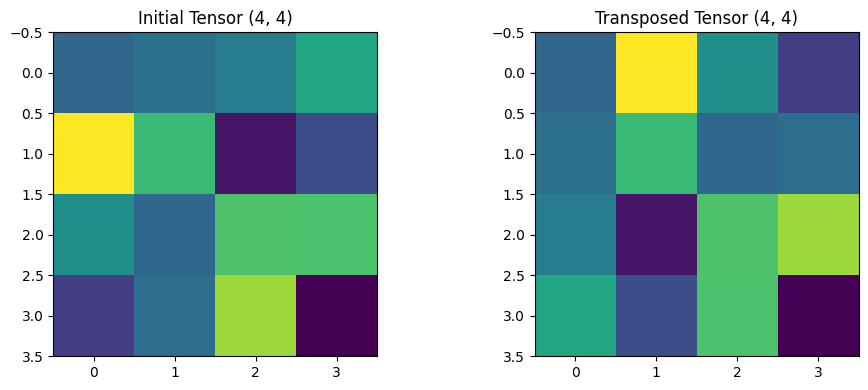

In [29]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Note: Cuda type tensors need be of float types and converted to numpy to visualize
fTen = ten4x4.float()
fTenCPU = fTen.cpu().numpy()
fTenCPU_transpose = fTenCPU.transpose()

# Plot initial tensor
im1 = ax1.imshow(fTenCPU, cmap='viridis')
ax1.set_title(f"Initial Tensor {fTenCPU.shape}")

# Plot transposed tensor
im2 = ax2.imshow(fTenCPU_transpose, cmap='viridis')
ax2.set_title(f"Transposed Tensor {fTenCPU_transpose.shape}")

plt.tight_layout()
plt.show()

## **Day 2**

### **Autograd – The Engine of Machine Learning**

  Welcome back. Yesterday was about the "containers" (Tensors); today is about the math that makes them learn.

  In AI, we don't tell the computer the rules. We give it an equation with random weights, show it the error (Loss), and ask it to fix itself. Autograd is the tool that calculates exactly how much each weight contributed to that error.


---


#### **The Core Concept: Gradients**
  A gradient is just a fancy word for a slope or derivative. If our Loss is a mountain, the gradient tells us which way is "downhill" so we can reach the bottom (the perfect answer).

  When you create a tensor in PyTorch and set `requires_grad=True`, PyTorch starts tracking every operation you do to it. It builds a Computational Graph in the background.

### **Exercise: Manual vs. Auto Differentiation**

In [2]:
import torch

# 1. Create a tensor and tell PyTorch to track it
x = torch.tensor(3.0, requires_grad=True)

# 2. Define a function: y = x^2
y = x**2

# 3. Backpropagate! This calculates the derivative dy/dx
y.backward()

# 4. Check the result
# Since y = x^2, the derivative is 2x.
# If x=3, the gradient should be 2*3 = 6.
print(f"Input x: {x.item()}")
print(f"Function y: {y.item()}")
print(f"PyTorch calculated gradient (dy/dx): {x.grad}")

Input x: 3.0
Function y: 9.0
PyTorch calculated gradient (dy/dx): 6.0


### **Homework**

#### **Mission**

1. **Chain Reactions**: Create three tensors: a, b and c. Let 𝑄 = (𝐚 * 𝐛) + 𝐜. Use `Q.backward()` and see if you can manually predict what `a.grad` and `b.grad` will be.
2. **The Stop-Gradient**: Sometimes we don't want to train part of a model. Research `torch.no_grad()` or `.detach()`. Try to perform a math operation on a tensor so that `.backward()` fails or returns nothing.
3. **Visualization**: If you have extra time, look up torchviz. It's a library that can actually draw the computational graph for you in Colab!


In [10]:
# Create three tensors: a, b and c. Let 𝑄 = (𝐚 * 𝐛) + 𝐜. Use Q.backward() and see if you can manually predict what a.grad and b.grad will be.

a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
c = torch.tensor(2.0, requires_grad=True)

Q = (a * b) + c

Q.backward()

# Check result
# since q = ab + c, the derivative is dq = a.db + b.da + dc
# partial derivatives
# a.grad = 3
# b.grad = 2
print(f"Input a: {a.item()}")
print(f"Input b: {b.item()}")
print(f"Input c: {c.item()}")
print(f"Function q: {Q.item()}")
print(f"PyTorch calculated gradient of a: {a.grad}")
print(f"PyTorch calculated gradient of b: {b.grad}")

# Research torch.no_grad()

x = torch.tensor(5.0, requires_grad=True)
with torch.no_grad():
  y = x * 2
print(f"Function y: {y.requires_grad}")
# Exception scenario, because a new tensor is created.
with torch.no_grad():
  a = torch.nn.Parameter(torch.rand(10))
print(f"Function a: {a.requires_grad}")

Input a: 2.0
Input b: 3.0
Input c: 2.0
Function q: 8.0
PyTorch calculated gradient of a: 3.0
PyTorch calculated gradient of b: 2.0
Function y: False
Function a: True


In [11]:
!pip install torchviz

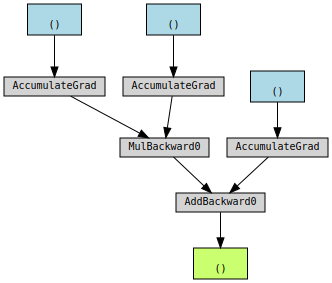

In [13]:
from torchviz import make_dot


make_dot(Q)

